<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/Taller_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3. 10 Puntos Se desea evaluar la eficacia de cuatro tipos de fertilizantes sobre el crecimiento de
plantas. Las alturas medidas al mes (en cm) son:
Fertilizante 1 (n1 = 8): 15, 16, 14, 17, 15, 16, 14, 15.
Fertilizante 2 (n2 = 8): 18, 17, 19, 18, 17, 20, 19, 18.
Fertilizante 3 (n3 = 8): 16, 15, 16, 15, 16, 15, 16, 15.
Fertilizante 4 (n4 = 8): 20, 21, 19, 20, 22, 21, 20, 19.
Realice la prueba ANOVA de una vía con α = 0,05 para determinar si hay diferencias significativas
en el crecimiento promedio según el fertilizante utilizado.

DATOS ORIGINALES:
      Fertilizante  Altura
0   Fertilizante 1      15
1   Fertilizante 1      16
2   Fertilizante 1      14
3   Fertilizante 1      17
4   Fertilizante 1      15
5   Fertilizante 1      16
6   Fertilizante 1      14
7   Fertilizante 1      15
8   Fertilizante 2      18
9   Fertilizante 2      17
10  Fertilizante 2      19
11  Fertilizante 2      18
12  Fertilizante 2      17
13  Fertilizante 2      20
14  Fertilizante 2      19
15  Fertilizante 2      18
16  Fertilizante 3      16
17  Fertilizante 3      15
18  Fertilizante 3      16
19  Fertilizante 3      15
20  Fertilizante 3      16
21  Fertilizante 3      15
22  Fertilizante 3      16
23  Fertilizante 3      15
24  Fertilizante 4      20
25  Fertilizante 4      21
26  Fertilizante 4      19
27  Fertilizante 4      20
28  Fertilizante 4      22
29  Fertilizante 4      21
30  Fertilizante 4      20
31  Fertilizante 4      19

Medias por Fertilizante:
  Fertilizante 1: 15.2500
  Fertilizante 2: 18.2500
  Fertilizant

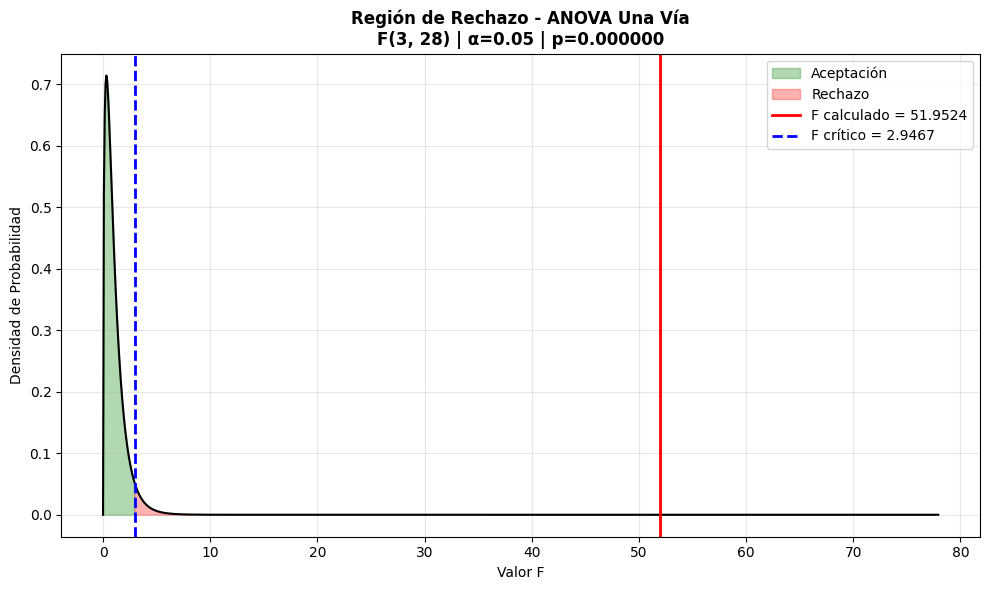

ANÁLISIS COMPLETO FINALIZADO


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ============================================================================
# DATOS DEL PROBLEMA
# ============================================================================

# Datos de los fertilizantes proporcionados por el usuario
fertilizer1 = [15, 16, 14, 17, 15, 16, 14, 15]
fertilizer2 = [18, 17, 19, 18, 17, 20, 19, 18]
fertilizer3 = [16, 15, 16, 15, 16, 15, 16, 15]
fertilizer4 = [20, 21, 19, 20, 22, 21, 20, 19]

# Creación del DataFrame
data_fertilizers = {
    'Fertilizante': ['Fertilizante 1'] * len(fertilizer1) +
                    ['Fertilizante 2'] * len(fertilizer2) +
                    ['Fertilizante 3'] * len(fertilizer3) +
                    ['Fertilizante 4'] * len(fertilizer4),
    'Altura': fertilizer1 + fertilizer2 + fertilizer3 + fertilizer4
}

df_fertilizer = pd.DataFrame(data_fertilizers)
fertilizantes = df_fertilizer['Fertilizante'].unique()

# ============================================================================
# CÁLCULOS PRELIMINARES
# ============================================================================

datos_alturas = [df_fertilizer[df_fertilizer['Fertilizante'] == f]['Altura'].values for f in fertilizantes]
n_grupos = len(fertilizantes)
n_obs = [len(g) for g in datos_alturas]
n_total = sum(n_obs)

media_global = df_fertilizer['Altura'].mean()
medias_fertilizante = df_fertilizer.groupby('Fertilizante')['Altura'].mean().values

print("DATOS ORIGINALES:")
print(df_fertilizer)
print("\nMedias por Fertilizante:")
for i, fertilizante in enumerate(fertilizantes):
    print(f"  {fertilizante}: {medias_fertilizante[i]:.4f}")
print(f"Media Global: {media_global:.4f}\n")

# ============================================================================
# ANOVA DE UNA VÍA MANUAL
# ============================================================================

SCT = np.sum((df_fertilizer['Altura'] - media_global)**2)
SCB = sum([n_obs[i]*(medias_fertilizante[i] - media_global)**2 for i in range(n_grupos)])
SCE = SCT - SCB

gl_b = n_grupos - 1
gl_e = n_total - n_grupos
gl_t = n_total - 1

CMb = SCB / gl_b
CMe = SCE / gl_e

F = CMb / CMe
alpha = 0.05 # Nivel de significancia
p_value = 1 - stats.f.cdf(F, gl_b, gl_e)
F_crit = stats.f.ppf(1 - alpha, gl_b, gl_e)

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("TABLA ANOVA DE UNA VÍA")
print("="*80)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12}")
print("-"*80)
print(f"{'Entre Fertilizantes':<20} {SCB:>12.4f} {gl_b:>6} {CMb:>12.4f} {F:>12.4f} {p_value:>12.6f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_e:>6} {CMe:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_t:>6}")
print("="*80)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

print(f"\nINTERPRETACIÓN ANOVA (α = {alpha}):")
print(f"  F calculado = {F:.4f}")
print(f"  F crítico = {F_crit:.4f}")
print(f"  Valor-p = {p_value:.6f}")

if p_value < alpha:
    print("  ✓ Hay diferencias significativas entre las medias de crecimiento según el fertilizante utilizado.\n")
else:
    print("  ✗ No hay diferencias significativas entre las medias de crecimiento según el fertilizante utilizado.\n")

# ============================================================================
# ANÁLISIS POST-HOC DE TUKEY (HSD)
# ============================================================================

if p_value < alpha:
    print("ANÁLISIS POST-HOC DE TUKEY (HSD):")
    tukey_result = pairwise_tukeyhsd(endog=df_fertilizer['Altura'], groups=df_fertilizer['Fertilizante'], alpha=alpha)
    print(tukey_result)
    print("\nINTERPRETACIÓN TUKEY:")
    print("  Las columnas 'reject' indican si la hipótesis nula (no diferencia entre las medias) se rechaza.")
    print("  'True' significa que hay una diferencia significativa entre los pares de grupos.\n")
else:
    print("No se requiere un análisis Post-Hoc de Tukey, ya que el ANOVA no encontró diferencias significativas.")

# ============================================================================
# GRÁFICO DE REGIÓN DE RECHAZO
# ============================================================================

x = np.linspace(0, max(F, F_crit)*1.5, 1000)
y = stats.f.pdf(x, gl_b, gl_e)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=1.5)
plt.fill_between(x[x <= F_crit], y[x <= F_crit], color='green', alpha=0.3, label='Aceptación')
plt.fill_between(x[x >= F_crit], y[x >= F_crit], color='red', alpha=0.3, label='Rechazo')
plt.axvline(F, color='red', linewidth=2, label=f'F calculado = {F:.4f}')
plt.axvline(F_crit, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit:.4f}')
plt.title(f'Región de Rechazo - ANOVA Una Vía\nF({gl_b}, {gl_e}) | α={alpha} | p={p_value:.6f}', fontsize=12, fontweight='bold')
plt.xlabel('Valor F')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)
